In [33]:
#Thư viện:
import pandas as pd
import numpy as np
import torch
import seaborn as sns
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

In [3]:
#data train, test:
#train:
df = pd.read_csv("data/fashion-mnist_train.csv")
#test:
df_test = pd.read_csv("data/fashion-mnist_test.csv")

In [4]:
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
#Tạo label số tương ứng với trang phục 
fashion_mnist_labels = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

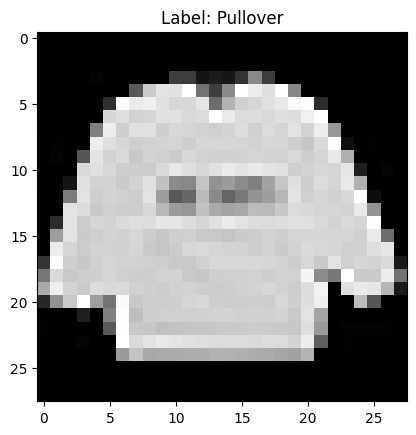

In [6]:
image = df.iloc[0, 1:].to_numpy().reshape(28, 28) # chỉnh hình về dạng 28x28 pixels
image_label = fashion_mnist_labels[df.iloc[0, 0]]

plt.imshow(image, cmap='gray')
plt.title(f"Label: {image_label}")
plt.show()

In [7]:
# Chuẩn hoá giá trị pixel từ phạm vi (0-255) đến (0-1):
X = df.iloc[:, 1:] / 255.0
y = df.iloc[:, 0]

X_test = df_test.iloc[:, 1:] / 255.0
y_test = df_test.iloc[:, 0]

In [8]:
# Định dạng hình ảnh để phù hợp với mô hình CNN:
X = X.values.reshape(-1, 28, 28, 1)
X_test = X_test.values.reshape(-1, 28, 28, 1)

In [10]:
#Mã hoá nhãn bằng LabelEncoder:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)
y_test = label_encoder.transform(y_test)

In [ ]:
from sklearn.model_selection import train_test_split

# Chia dữ liệu thành các tập huấn luyện, xác thực và kiểm tra:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

# Hiển thị hình dạng tập dữ liệu
print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)
print("X_test shape:", X_test.shape)
print("===================================")
print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

X_train shape: (38400, 28, 28, 1)
X_val shape: (9600, 28, 28, 1)
X_test shape: (12000, 28, 28, 1)
y_train shape: (38400,)
y_val shape: (9600,)
y_test shape: (12000,)


In [38]:
#Xây dựng mô hình CNN
import tensorflow as tf

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(64, (3,3), activation='relu', input_shape=(28, 28, 1)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),

    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D((2,2)),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [39]:
#cấu hình mô hình:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [44]:
#Train mô hình:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_val, y_val))
train_loss = history.history['loss']
val_loss = history.history['val_loss']

Epoch 1/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 34s 26ms/step - accuracy: 0.6661 - loss: 1.0297 - val_accuracy: 0.8523 - val_loss: 0.3963
Epoch 2/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8333 - loss: 0.4518 - val_accuracy: 0.8790 - val_loss: 0.3318
Epoch 3/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.8598 - loss: 0.3861 - val_accuracy: 0.8942 - val_loss: 0.2970
Epoch 4/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 32s 27ms/step - accuracy: 0.8737 - loss: 0.3462 - val_accuracy: 0.9014 - val_loss: 0.2743
Epoch 5/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 32s 26ms/step - accuracy: 0.8822 - loss: 0.3269 - val_accuracy: 0.9057 - val_loss: 0.2707
Epoch 6/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 33s 27ms/step - accuracy: 0.8891 - loss: 0.3097 - val_accuracy: 0.8966 - val_loss: 0.2878
Epoch 7/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 33s 28ms/step - accuracy: 0.8939 - loss: 0.2927 - val_accuracy: 0.9008 - val_loss: 0.2813
Epoch 8/50
1200/1200 ━━━━━━━━━━━━━━━━━━━━ 34s 28ms/step - accuracy: 0.9029 -

In [45]:
#Đánh giá mô hình:
test_loss, test_acc = model.evaluate(X_test, y_test)

print('Test accuracy:', test_acc)
print("Test loss:", test_loss)

375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9322 - loss: 0.2019
Test accuracy: 0.9303333163261414
Test loss: 0.2098948210477829


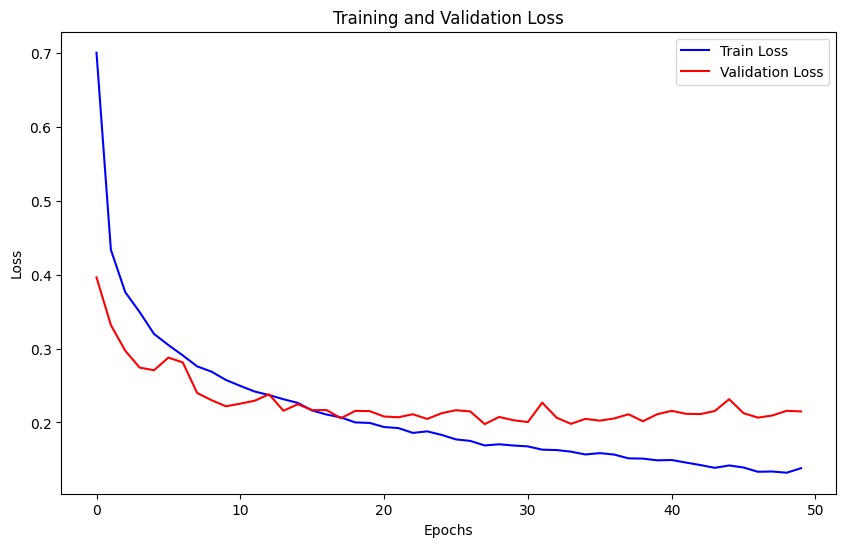

In [46]:
plt.figure(figsize=(10, 6))
plt.plot(train_loss, 'b', label='Train Loss')
plt.plot(val_loss, 'r', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

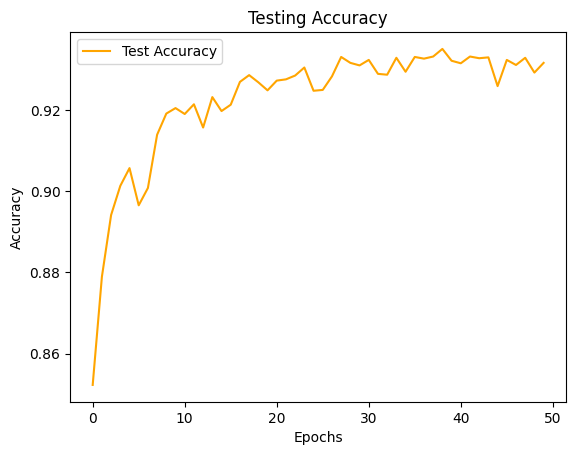

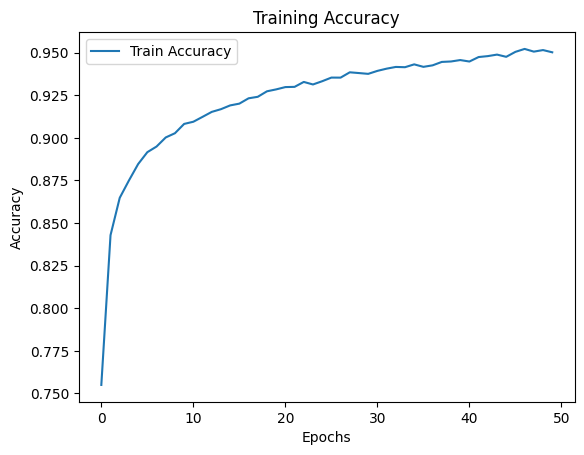

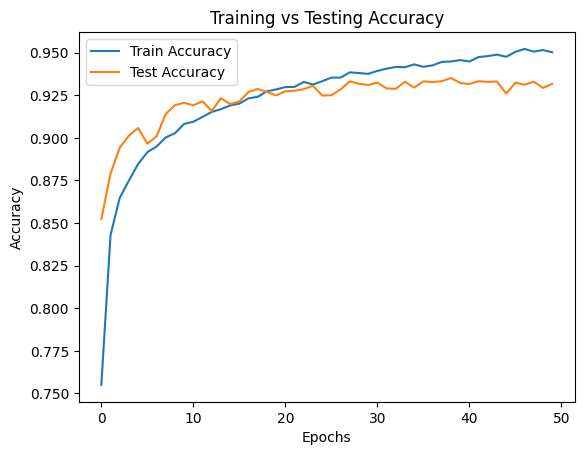

In [47]:
plt.plot(history.history['val_accuracy'], label='Test Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Testing Accuracy')
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training Accuracy')
plt.show()

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Test Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Testing Accuracy')
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


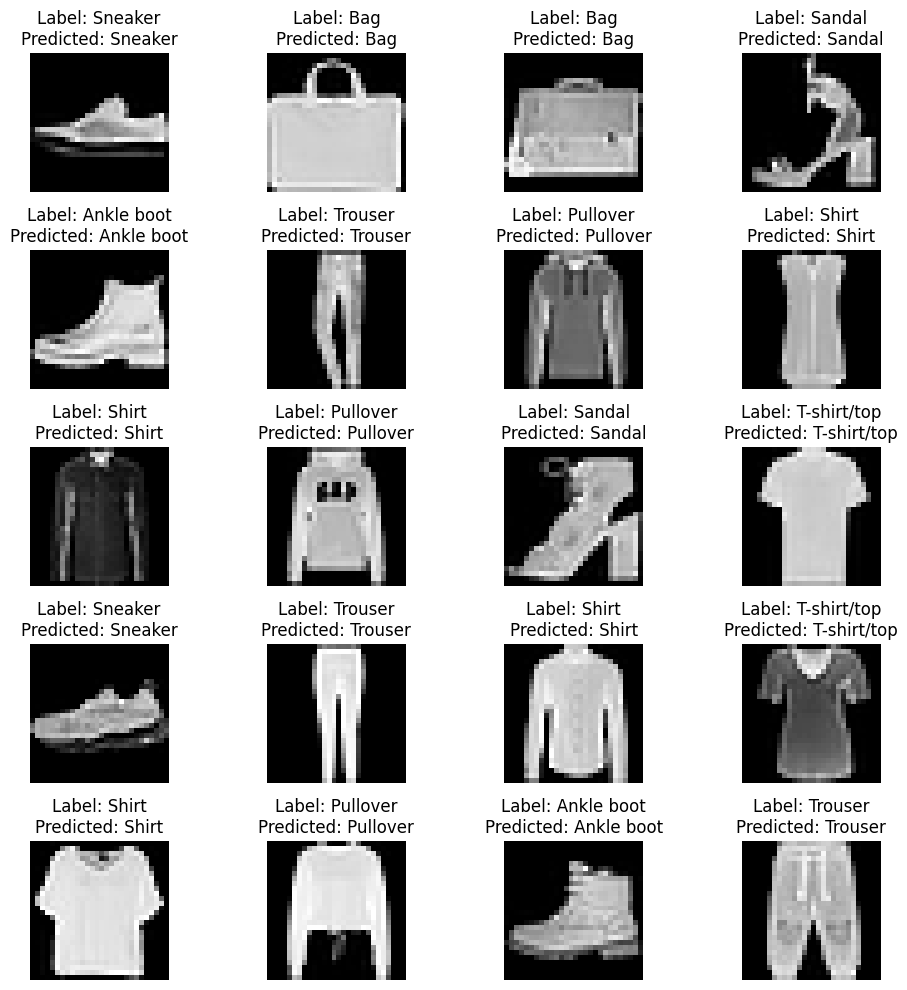

In [48]:
n_samples = 20
plt.figure(figsize=(10, 10))
for i in range(n_samples):
    plt.subplot(5, 4, i+1)
    image = X_test[i]
    image_label = fashion_mnist_labels[y_test[i]]
    prediction = model.predict(image.reshape(1, 28, 28, 1))
    predicted_label = fashion_mnist_labels[np.argmax(prediction)]

    plt.imshow(image.reshape(28, 28), cmap='gray')
    plt.title(f"Label: {image_label}\nPredicted: {predicted_label}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [49]:
torch.save(model, "CNN_fashion.pth")